In [3]:
# Les deux premières lignes permettent le partage via Binder
%pip install scipy
%pip install Pillow

# Ces packages sont utilisés dans le code. 
import numpy as np
import scipy as sc
from PIL import Image

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


<div class="alert alert-block alert-info">
    
## A propos des notebook Jupyter
<div class="alert alert-success" style="margin-top: 1em">


L'environnement de code dans lequel vous vous trouvez est un notebook jupyter. Il vous permet de coder en python sans n'avoir rien à installer sur votre machine. Chaque cellule contient soit du texte (comme celle-ci) soit du code python. Pour executer le code contenu dans une cellule vous pouvez soit appuyer sur l'icone "Run" tout en haut soit utiliser le raccourci clavier Ctrl + Entrée. 
Les sorties de votre code s'affiche juste sous la cellule executée. pour accéder au contenu d'une variable vous pouvez utiliser les fonctions print() et display(). 

</div>


### Sommaire

* [1. Chargement et affichage de l'image](#section1)
* [2. Affichage et obtention de la couleur d'un pixel](#section2)
* [3. Transformation en gris](#section3)
    * [3.1 Transformation d'un pixel ](#section31)
    * [3.2 Transformation de toute l'image](#section32)
    * [3.3 Rang et Noyau de la matrice G](#section33)
* [4. Transformation en Sépia ](#section4)
    * [4.1 Transformation d'un pixel](#section41)
    * [4.2 Transformation de toute l'image](#section42)
    * [5.3 Rang et Noyau de la matrice S](#section43)

</div>

<div class="alert alert-block alert-info">

## 1. Chargement et affichage de l'image <a class="anchor" id="section1"></a>

</div>

JPEG (225, 225) RGB


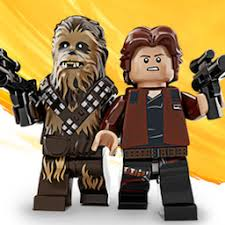

In [50]:
img = Image.open("solo.jpeg")
print(img.format,img.size,img.mode)
display(img)

<div class="alert alert-block alert-info">
    
## 2. Affichage et obtention de la couleur d'un pixel <a class="anchor" id="section2"></a>

</div>

position du pixel dans l'image : ligne 50  colonne 110
valeurs (r g b) du pixel choisi : 98 73 43


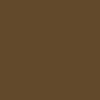

In [5]:
#coordonnées du pixel affichée : i-ème ligne et j-ème colonne
i=50
j=110
print("position du pixel dans l'image : ligne",i," colonne", j)

# Récupération des valeurs r,g,b du pixel
r,g,b = img.getpixel((i,j))
print("valeurs (r g b) du pixel choisi :", r,g,b)

# Affichage du pixel choisi (la taille est augmentée pour le rendre visible). 
pixel = Image.new("RGB",(1,1),(r,g,b))
scaled_pixel = pixel.resize((100, 100), Image.NEAREST)
display(scaled_pixel)

<div class="alert alert-block alert-info">

## 3. Transformation en gris <a class="anchor" id="section3"></a>


</div>

<div class="alert alert-block alert-info">
    
### 3.1 Transformation d'un pixel <a class="anchor" id="section31"></a>

La matrice $G$ permettant de passer d'un pixel au pixel gris correspondant est 
$$ G = \begin{pmatrix} 0.2126 & 0.7152 & 0.0722 \\ 0.2126 & 0.7152 & 0.0722 \\ 0.2126 & 0.7152 & 0.0722 \end{pmatrix}$$
On obtient le pixel gris $p'$ à partir du pixel de couleur $p$ par l'opération 
$$ p' = Gp$$
</div>

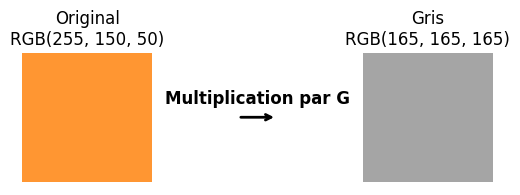

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Définition du pixel d'origine (r, g, b)
# On choisit une couleur vive pour bien voir la transformation
r, g, b = 255, 150, 50 
pixel_couleur = np.array([r, g, b])

# 2. Définition de la matrice G
# La luminance est calculée selon l'équation : 0.2126*r + 0.7152*g + 0.0722*b
G = np.array([
    [0.2126, 0.7152, 0.0722],
    [0.2126, 0.7152, 0.0722],
    [0.2126, 0.7152, 0.0722]
])

# 3. Calcul du pixel gris (transformation linéaire)
# On arrondit car les composantes d'un pixel sont des entiers
pixel_gris = np.dot(G, pixel_couleur).astype(int)

# 4. Affichage avec Matplotlib
fig, ax = plt.subplots(1, 3, figsize=(5, 2), gridspec_kw={'width_ratios': [1, 0.5, 1]})

# Affichage du pixel original
# On divise par 255 pour que Matplotlib comprenne les couleurs (échelle 0 à 1)
ax[0].imshow([[pixel_couleur / 255]])
ax[0].set_title(f"Original\nRGB({r}, {g}, {b})")
ax[0].axis('off')

# Dessin de la flèche de transformation
ax[1].annotate('', xy=(0.8, 0.5), xycoords='axes fraction', xytext=(0.2, 0.5),
            arrowprops=dict(arrowstyle="->", color='black', lw=2))
ax[1].text(0.5, 0.6, 'Multiplication par G', transform=ax[1].transAxes, ha='center', fontsize=12, fontweight='bold')
ax[1].axis('off')

# Affichage du pixel gris
ax[2].imshow([[pixel_gris / 255]])
ax[2].set_title(f"Gris\nRGB({pixel_gris[0]}, {pixel_gris[1]}, {pixel_gris[2]})")
ax[2].axis('off')

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">

### 3.2 Transformation de toute l'image <a class="anchor" id="section32"></a>

</div>

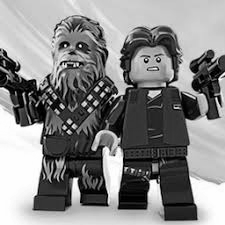

In [13]:
# On définit la fonction grey_transform qui applique la matrice G à tous les pixels de l'image donnée en argument. 
def grey_transform(img):
    pixels_grey = np.zeros((img.size[0],img.size[1],3))
    img_unif1_grey = Image.new("RGB",img.size)
    for i in range(225):
        for j in range(225): 
            r,g,b = img.getpixel((i,j))
            pixels_grey[i,j] = np.dot(G,np.array([r,g,b]))
            img_unif1_grey.putpixel((i,j),(pixels_grey[i,j,0].astype(int),pixels_grey[i,j,1].astype(int),pixels_grey[i,j,2].astype(int)))
    return img_unif1_grey


# On transforme tous les pixels de l'image en gris et on affiche l'image
img_gris = grey_transform(img)
display(img_gris)

<div class="alert alert-block alert-info">
    
### 3.3 Rang et noyau de la matrices $G$ <a class="anchor" id="section33"></a>

La transformation en gris n'est pas inversibles. La matrice $G$ est de rang $1$. Cela signifie qu'en transformant l'image par $G$ on perd de l'information puisqu'un pixel qui s'écrivait avant avec trois degrés de liberté ne peut plusn s'écrire qu'avec un degré de liberté (tous les pixels sont sur une même droite vectorielle de $R^3$.

Il y a plusieurs manières de rendre cela visible, nous proposons la démarche ci-dessous dans les cellules suivantes : 
* 1. Calculer le rang et le noyau de la matrice à l'aide de la libraire linalg
* 2. Construire une image couleur qui après transformation en noir et blanc devient uniforme
* 3. Visualiser les pixels de l'image dans R^3 avant et après la transformation en noir et blanc.  
</div>

In [32]:
import numpy as np
import scipy.linalg

# 1. Calcul du rang
rang_G = np.linalg.matrix_rank(G)
print(f"Le rang de la matrice G est : {rang_G}")

# 2. Calcul du noyau (Kernel)
noyau_G = scipy.linalg.null_space(G)
print("\nUne base du noyau de G (vecteurs qui deviennent noirs) :")
print((noyau_G * 100).astype(int))

Le rang de la matrice G est : 1

Une base du noyau de G (vecteurs qui deviennent noirs) :
[[-95 -12]
 [ 29  -6]
 [-10  98]]


<div class="alert alert-block alert-info">
Pour créer la deuxième illustration, nous avons besoin répondre à la question suivante : étant donné deux pixels $p_1$ et $p_2$ à quels conditions sont-ils envoyés sur le même pixel gris? Formalisons. Cela donne : 

$$ \text{soient } p_1,p_2 \in \mathbb{R}^3 \text{ tels que }\, \,  Gp_1 = Gp_2 $$
Alors on a : 
$$ Gp_1 - Gp_2 = 0 $$
$$\iff  G(p_1 - p_2) = 0 $$
$$ \iff p_1 - p_2 \in \mathrm{ker}(G) $$

Ainsi, il faut (et il suffit) que $p_1-p_2$ soit dans le noyau de la matrice $G$ !

Nous venons de trouver 
$$ \ker(G) = \mathrm{Vect}(v_1,v_2) $$
avec $v_1 = \begin{pmatrix} -95 \\ 29 \\ 10 \end{pmatrix}$ et $v_2 = \begin{pmatrix} -12 \\ -6 \\ 98 \end{pmatrix}$. Remarquez que la base trouvée pour le noyau de $G$ contient des vecteurs de $\mathbb{R}^3$ qui ne peuvent pas être interpretés comme des pixels puisque les coordonnées ne sont pas dans $[0,255]$. Cela n'est pas tellement important puisque pour la suite ce qui sera important c'est que la différence de deux pixels $p1$ et $p2$ soit dans le noyau de $G$ !

Pour cela, nous allons transformer l'image de départ (solo.jpeg) pour qu'elle ne contienne que des pixels qui diffèrent entre eux d'un élément du noyau de $G$. Comme les valeurs r,g,b des pixels doivent être comprises entre 0 et 255 on va obtenir un nombre fini de pixel possible. Concrètement, on part d'un pixel $p$ quelconque et on construit

$$
\begin{array}{lll}
p_1 = p + v_1 & p_2 = p + 2v_1 & p_3 = p + 3v_1   \\
q_1 = p + v_2 & q_2 = p + 2v_2 & q_3 = p + 3v_2  \\
r_1 = p + v_1 + v_2 & & \\ 
\end{array}
$$


Tous ces pixels ont la même image par la matrice $G$ !
$$ Gp = Gp_1 = Gp_2 = \cdot \cdot \cdot = Gr_1 $$

On va ensuite reconstruire l'image en utilisant uniquement les pixels $(p,p_1,p_2,p_3,q_1,q_2,q_3,r_1)$. 
On utilisera pour cela la fonction closest_pixel qui envoie un pixel de couleur quelconque sur le pixel le plus proche dans une liste donnée en argument.
</div>

Vérification : les valeurs hors [0, 255] sont automatiquement corrigées (clipped).

Ci-dessous : voici toutes les couleurs qui vont être envoyées sur la même teinte de gris et qui peuvent être utilisées pour générer une image qui deviendra uniforme après application de la transformation


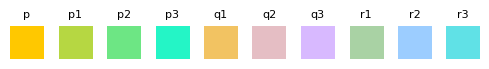

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Fonctions optimisées avec NumPy
def closest_pixel(p, pixels):
    """Trouve le pixel le plus proche en utilisant la vectorisation NumPy."""
    distances = np.linalg.norm(pixels - p, axis=1)
    return pixels[np.argmin(distances)]

# 2. Définition des pixels (p, v1, v2 doivent être définis précédemment)
p = np.array([255, 200, 0])
# On crée un dictionnaire pour associer un nom à chaque vecteur pour l'affichage
pixels_dict = {
    "p": p,
    "p1": p + v1, "p2": p + 2*v1, "p3": p + 3*v1,
    "q1": p + v2, "q2": p + 2*v2, "q3": p + 3*v2,
    "r1": p + v1 + v2, "r2": p + v1 + 2*v2, "r3": p + 2*v1 + v2
}

# 3. Traitement et vérification
print("Vérification : les valeurs hors [0, 255] sont automatiquement corrigées (clipped).\n")
print("Ci-dessous : voici toutes les couleurs qui vont être envoyées sur la même teinte de gris et qui peuvent être utilisées pour générer une image qui deviendra uniforme après application de la transformation")

# On prépare la figure (2 lignes, 5 colonnes)
# 3. Affichage : On divise figsize par 3 (anciennement 15x6, maintenant 5x2)
fig, axes = plt.subplots(1, 10, figsize=(5, 2))
axes = axes.flatten()

for i, (name, val) in enumerate(pixels_dict.items()):
    # Sécurité : on reste dans [0, 255]
    pixel_clean = np.clip(val, 0, 255).astype(int)
    
    # Affichage du carré
    axes[i].imshow([[pixel_clean / 255]])
    
    # On réduit la taille de la police (fontsize) pour que ce soit lisible en petit
    axes[i].set_title(f"{name}", fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(224.5), np.float64(224.5), np.float64(-0.5))

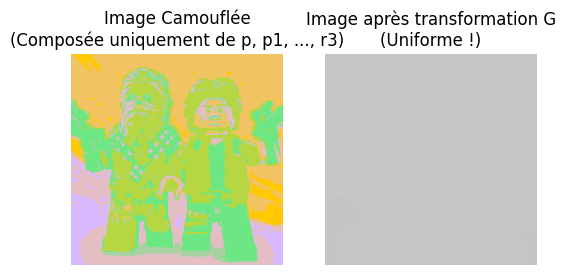

In [48]:
# Creation d'une image basée sur solo.jpeg mais ne contenant que les pixels p,p1,...,r3 ci-dessus
img_unif_grey = Image.new("RGB",(225,225));
candidates = np.array(list(pixels_dict.values()));
for i in range(225):
    for j in range(225):
        r,g,b = img.getpixel((i,j));
        pix = np.array([r,g,b]);
        closest_pix = closest_pixel(pix,candidates);
        img_unif_grey.putpixel((i,j),(closest_pix[0],closest_pix[1],closest_pix[2]));
        
# Affichage des résultats 
fig, axes = plt.subplots(1, 2, figsize=(6, 6));

axes[0].imshow(img_unif_grey)
axes[0].set_title("Image Camouflée\n(Composée uniquement de p, p1, ..., r3)")
axes[0].axis('off')

axes[1].imshow(grey_transform(img_unif_grey))
axes[1].set_title("Image après transformation G\n(Uniforme !)")
axes[1].axis('off')



<div class="alert alert-block alert-info">
Cette cellule produit un graphique interactif permettant d'observer la "compression" de l'espace des couleurs. 
On y distingue le nuage des pixels originaux (en marron), leur projection sur la droite des gris (l'image de $G$ de dimension 1), 
ainsi que nos "pixels candidats" : ces derniers illustrent parfaitement la notion de noyau. 
Bien que ces couleurs soient distinctes dans le cube RGB, elles s'alignent selon les directions du noyau $\ker(G)$ 
pour finir "écrasées" sur un seul et même point de la droite grise.
</div>

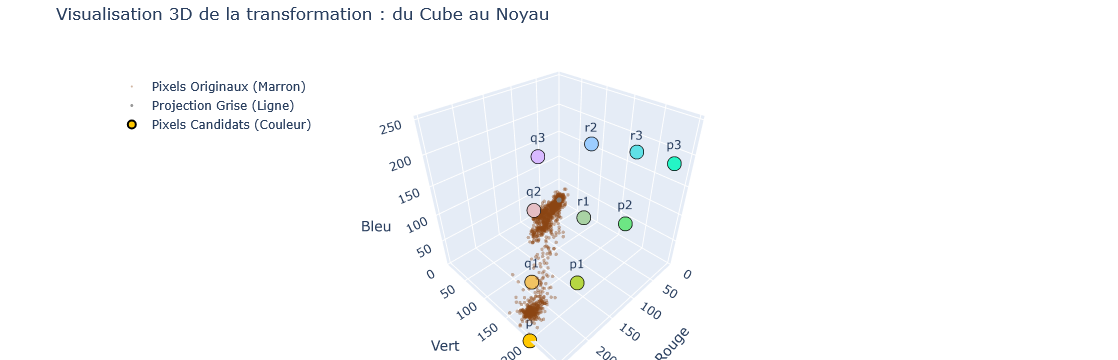

In [49]:
import numpy as np
import plotly.graph_objects as go

# 1. Préparation des données
# On récupère l'image sous forme de liste de pixels (H*W, 3)
img_flat = np.array(img).reshape(-1, 3)

# On échantillonne 2000 pixels au hasard pour ne pas ralentir le graphique
n_samples = 2000
idx = np.random.choice(len(img_flat), n_samples, replace=False)
pixels_sample = img_flat[idx]

# Calcul des pixels transformés en gris (Gris = G * Pixel)
pixels_gris = (pixels_sample @ G.T)

# Récupération des candidats (p, p1, p2, ...)
candidats_vals = np.array(list(pixels_dict.values()))
candidats_vals = np.clip(candidats_vals, 0, 255) # Sécurité

# 2. Création de la figure interactive avec Plotly
fig = go.Figure()

# --- TRACE 1 : Pixels originaux (en marron) ---
fig.add_trace(go.Scatter3d(
    x=pixels_sample[:, 0], y=pixels_sample[:, 1], z=pixels_sample[:, 2],
    mode='markers',
    marker=dict(size=2, color='saddlebrown', opacity=0.4),
    name='Pixels Originaux (Marron)'
))

# --- TRACE 2 : Pixels Gris (sur la diagonale r=g=b) ---
fig.add_trace(go.Scatter3d(
    x=pixels_gris[:, 0], y=pixels_gris[:, 1], z=pixels_gris[:, 2],
    mode='markers',
    marker=dict(size=3, color='gray', opacity=0.8),
    name='Projection Grise (Ligne)'
))

# --- TRACE 3 : Pixels Candidats (leurs couleurs réelles) ---
# On les affiche un peu plus gros pour bien les voir
fig.add_trace(go.Scatter3d(
    x=candidats_vals[:, 0], y=candidats_vals[:, 1], z=candidats_vals[:, 2],
    mode='markers+text',
    text=list(pixels_dict.keys()),
    marker=dict(
        size=8, 
        color=['rgb({},{},{})'.format(r,g,b) for r,g,b in candidats_vals],
        line=dict(color='black', width=2)
    ),
    name='Pixels Candidats (Couleur)'
))

# Configuration des axes et du titre
fig.update_layout(
    title="Visualisation 3D de la transformation : du Cube au Noyau",
    scene=dict(
        xaxis_title='Rouge',
        yaxis_title='Vert',
        zaxis_title='Bleu',
        xaxis=dict(range=[0, 255]),
        yaxis=dict(range=[0, 255]),
        zaxis=dict(range=[0, 255]),
        aspectmode='cube' # Garde le cube proportionné
    ),
    margin=dict(l=0, r=0, b=0, t=40),
    legend=dict(yanchor="top", y=0.9, xanchor="left", x=0.1)
)

fig.show()

<div class="alert alert-block alert-info">

# 4 Transformation en Sepia<a class="anchor" id="section4"></a>

La matrice $S$ permettant de passer d'un pixel au pixel gris correspondant est 
$$ S = \begin{pmatrix} 0.393 & 0.769 & 0.189 \\ 0.349 & 0.686 & 0.168 \\ 0.272 & 0.534 & 0.131 \end{pmatrix}$$
On obtient le pixel sepia $p'$ à partir du pixel de couleur $p$ par l'opération 
$$ p' = Sp$$

</div>

<div class="alert alert-block alert-info">

## 4.1 Affichage et obtention de la couleur d'un pixel <a class="anchor" id="section41"></a>

</div>

position du pixel dans l'image : ligne 50  colonne 110
valeurs (r g b) du pixel choisi : 98 73 43


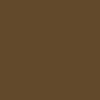

In [60]:
#coordonnées du pixel affichée : i-ème ligne et j-ème colonne
i=50
j=110
print("position du pixel dans l'image : ligne",i," colonne", j)

# Récupération des valeurs r,g,b du pixel
r,g,b = img.getpixel((i,j))
print("valeurs (r g b) du pixel choisi :", r,g,b)

# Affichage du pixel choisi (la taille est augmentée pour le rendre visible). 
pixel = Image.new("RGB",(1,1),(r,g,b))
scaled_pixel = pixel.resize((100, 100), Image.NEAREST)
display(scaled_pixel)

<div class="alert alert-block alert-info">
    
### 4.2 Transformation d'un pixel <a class="anchor" id="section41"></a>

La matrice $G$ permettant de passer d'un pixel au pixel gris correspondant est 
$$ G = \begin{pmatrix} 0.393 & 0.769 & 0.189 \\ 0.349 & 0.686 & 0.168 \\ 0.272 & 0.534 & 0.131 \end{pmatrix}$$
On obtient le pixel sépia $p'$ à partir du pixel de couleur $p$ par l'opération 
$$ p' = Sp$$
</div>

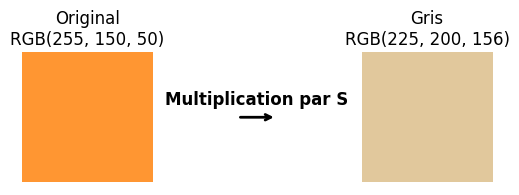

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Définition du pixel d'origine (r, g, b)
# On choisit une couleur vive pour bien voir la transformation
r, g, b = 255, 150, 50 
pixel_couleur = np.array([r, g, b])

# 2. Définition de la matrice S

S = np.array([
    [0.393, 0.769, 0.189],
    [0.349, 0.686, 0.168],
    [0.272, 0.534, 0.131]
])

# 3. Calcul du pixel sépia (transformation linéaire)
# On arrondit car les composantes d'un pixel sont des entiers
pixel_sepia = np.dot(S, pixel_couleur).astype(int)

# 4. Affichage avec Matplotlib
fig, ax = plt.subplots(1, 3, figsize=(5, 2), gridspec_kw={'width_ratios': [1, 0.5, 1]})

# Affichage du pixel original
# On divise par 255 pour que Matplotlib comprenne les couleurs (échelle 0 à 1)
ax[0].imshow([[pixel_couleur / 255]])
ax[0].set_title(f"Original\nRGB({r}, {g}, {b})")
ax[0].axis('off')

# Dessin de la flèche de transformation
ax[1].annotate('', xy=(0.8, 0.5), xycoords='axes fraction', xytext=(0.2, 0.5),
            arrowprops=dict(arrowstyle="->", color='black', lw=2))
ax[1].text(0.5, 0.6, 'Multiplication par S', transform=ax[1].transAxes, ha='center', fontsize=12, fontweight='bold')
ax[1].axis('off')

# Affichage du pixel gris
ax[2].imshow([[pixel_gris / 255]])
ax[2].set_title(f"Gris\nRGB({pixel_sepia[0]}, {pixel_sepia[1]}, {pixel_sepia[2]})")
ax[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# On définit la fonction grey_transform qui applique la matrice G à tous les pixels de l'image donnée en argument. 
def sepia_transform(img):
    pixels_sepia = np.zeros((img.size[0],img.size[1],3))
    img_unif1_sepia = Image.new("RGB",img.size)
    for i in range(225):
        for j in range(225): 
            r,g,b = img.getpixel((i,j))
            pixels_sepia[i,j] = np.dot(S,np.array([r,g,b]))
            img_unif1_sepia.putpixel((i,j),(pixels_sepia[i,j,0].astype(int),pixels_sepia[i,j,1].astype(int),pixels_sepia[i,j,2].astype(int)))
    return img_unif1_sepia


# On transforme tous les pixels de l'image en gris et on affiche l'image
img_sepia = sepia_transform(img)
display(img_sepia)

<div class="alert alert-block alert-info">
    
### 4.3 Rang et noyau de la matrices $S$ <a class="anchor" id="section43"></a>

La transformation en sépia, comme la transformation en gris n'est pas inversible! La matrice $S$ est de rang $2$. Cela signifie qu'en transformant l'image par $S$ on perd de l'information puisqu'un pixel qui s'écrivait avant avec trois degrés de liberté ne dispose plus que de deux degrés de liberté. 

Pour rendre cela tangible, nous pourrions tester les même étapes que pour la transformation en gris. Nous proposons de simplement visualiser le troisième point, c'est à dire que ce que deviennent les pixels dans $R^3$ après la transformation en sépia. 
 
</div>

In [ ]:
import numpy as np
import plotly.graph_objects as go

# 1. Préparation des données
# On récupère l'image sous forme de liste de pixels (H*W, 3)
img_flat = np.array(img).reshape(-1, 3)

# On échantillonne 2000 pixels au hasard pour ne pas ralentir le graphique
n_samples = 2000
idx = np.random.choice(len(img_flat), n_samples, replace=False)
pixels_sample = img_flat[idx]

# Calcul des pixels transformés en gris (Gris = G * Pixel)
pixels_sepia = (pixels_sample @ S.T)

# 2. Création de la figure interactive avec Plotly
fig = go.Figure()

# --- TRACE 1 : Pixels originaux (en marron) ---
fig.add_trace(go.Scatter3d(
    x=pixels_sample[:, 0], y=pixels_sample[:, 1], z=pixels_sample[:, 2],
    mode='markers',
    marker=dict(size=2, color='saddlebrown', opacity=0.4),
    name='Pixels Originaux (Marron)'
))

# --- TRACE 2 : Pixels Sepia (sur la diagonale r=g=b) ---
fig.add_trace(go.Scatter3d(
    x=pixels_sepia[:, 0], y=pixels_sepia[:, 1], z=pixels_sepia[:, 2],
    mode='markers',
    marker=dict(size=3, color='tan', opacity=0.8),
    name='Projection Sepia (Plan)'
))


# Configuration des axes et du titre
fig.update_layout(
    title="Visualisation 3D de la transformation : du Cube au Noyau",
    scene=dict(
        xaxis_title='Rouge',
        yaxis_title='Vert',
        zaxis_title='Bleu',
        xaxis=dict(range=[0, 255]),
        yaxis=dict(range=[0, 255]),
        zaxis=dict(range=[0, 255]),
        aspectmode='cube' # Garde le cube proportionné
    ),
    margin=dict(l=0, r=0, b=0, t=40),
    legend=dict(yanchor="top", y=0.9, xanchor="left", x=0.1)
)

fig.show()